In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn import hmm
import yfinance as yf
import os 
from arch import arch_model

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from scipy.optimize import minimize

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

In [2]:
start_date = "2024-01-01"
end_date = "2026-06-30"

VIX = yf.download("^VIX", start=start_date, end=end_date, interval='1d')
VIX.tail()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^VIX,^VIX,^VIX,^VIX,^VIX
Date,,,,,
2026-06-23,19.490000,20.540001,18.610001,19.670000,0
2026-06-24,18.629999,20.340000,18.040001,19.129999,0
2026-06-25,18.889999,19.950001,17.719999,18.110001,0
2026-06-26,18.410000,20.719999,18.200001,19.700001,0
2026-06-29,17.650000,19.450001,17.490000,18.600000,0


In [3]:
def build_stock_df(ticker, start=start_date, end=end_date, interval='1d', atr_period=14):
    df = pd.DataFrame(
        yf.download(ticker, start=start_date, end=end_date, interval=interval, auto_adjust=True)
    )

    df = df.dropna().copy()

    # If yfinance returns MultiIndex columns, flatten them
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df['Av Price'] = (df['High'] + df['Low'] + df['Close'] + df['Open']) / 4
    df['Tomorrow'] = df['Close'].shift(-1)
    df['log_ret'] = np.log(df['Close'] / df['Close'].shift(1))*100
    df['abs_return'] = np.abs(df['log_ret'])
    df['SMA21'] = df['Av Price'].rolling(window=21).mean()
    df['SMA50'] = df['Av Price'].rolling(window=50).mean()
    df['ATR'] = calc_atr(df, period=atr_period)
    df['rdv10'] = df['log_ret'].rolling(window=10).std()
    df['rdv20'] = df['log_ret'].rolling(window=20).std()
    df['rdv60'] = df['log_ret'].rolling(window=60).std()
    df['vol_ratio'] = (df['rdv10'])/(df['rdv60'])
    df['Pct Change'] = df['log_ret'].pct_change()
    df['rolling_kurt'] = df['log_ret'].rolling(20).kurt()
    df['rolling_skew'] = df['log_ret'].rolling(20).skew()
    running_peak = df['Close'].cummax()
    drawdown = (df['Close'] - running_peak) / running_peak
    df["Drawdown"] = drawdown
    df = df.dropna(subset=['SMA21', 'ATR'])

    return df

atr_period = 14

def calc_atr(df, period=20): # 20 for 3.33 day ATR on 4H intervals
    high = df['High'].squeeze()
    low = df['Low'].squeeze()
    close = df['Close'].squeeze()
    
    high_low = high - low
    high_close = (high - close.shift(1)).abs()
    low_close = (low - close.shift(1)).abs()
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    atr = tr.rolling(window=int(period)).mean()
    return atr

In [4]:
TSM = build_stock_df('TSM', start=start_date, end=end_date, interval='1d', atr_period=14)
last_TSM = TSM['Close'].iloc[-1]
TSM.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Av Price,Tomorrow,log_ret,abs_return,SMA21,SMA50,ATR,rdv10,rdv20,rdv60,vol_ratio,Pct Change,rolling_kurt,rolling_skew,Drawdown
Date,,,,,,,,,,,,,,,,,,,,
2024-01-31,109.337502,111.060418,109.260065,109.860185,12853900,109.879542,109.753723,-2.707360,2.707360,104.254255,NaN,3.073875,3.238112,2.410649,NaN,NaN,2.428889,9.697693,2.671842,-0.036671
2024-02-01,109.753723,110.373199,108.998738,110.150578,8807600,109.819060,112.038033,0.379953,0.379953,104.793993,NaN,3.022021,1.327422,2.370274,NaN,NaN,-1.140341,10.093492,2.718375,-0.033004
2024-02-02,112.038033,112.241297,110.266717,111.176574,10044000,111.430655,114.980553,2.059941,2.059941,105.474656,NaN,3.095307,1.447974,2.357194,NaN,NaN,4.421566,9.516438,2.577991,-0.012877
2024-02-05,114.980553,115.706501,112.841426,113.373783,13267600,114.225566,115.551613,2.592462,2.592462,106.325283,NaN,3.208694,1.572022,2.390401,NaN,NaN,0.258512,8.301542,2.350670,0.000000
2024-02-06,115.551613,117.109983,114.486890,116.267887,11503800,115.854093,120.972054,0.495429,0.495429,107.255418,NaN,3.165828,1.563353,2.356561,NaN,NaN,-0.808896,9.530007,2.579559,0.000000


In [5]:
TSM = TSM.sort_index()
VIX = VIX.sort_index()

TSM.index = TSM.index.tz_localize(None)
VIX.index = VIX.index.tz_localize(None)

VIX_close = VIX[("Close", "^VIX")].rename("vix_level").to_frame()

TSM = pd.merge_asof(
    TSM.sort_index(),
    VIX_close.sort_index(),
    left_index=True,
    right_index=True,
    direction="backward",
    tolerance=pd.Timedelta("1D")
)

TSM=TSM.dropna()

## Introducing the volatility features we will use for the HMM

In [7]:
train = TSM.loc["2024-01-01":"2025-12-31"].copy()
test = TSM.loc["2026-01-01":].copy()

features1 = [
    "log_ret",
    "vol_ratio",
    "rdv20",
]

features2 = [
    "log_ret",
    "vol_ratio",
    "rdv20",
    "vix_level",
    "rolling_kurt",
    "Drawdown",
    "Volume",
]

features3 = [
    "log_ret",
    "rdv20",
    "vix_level",
    "rolling_skew",
    "Drawdown",
    "Volume",
]


X1_train = train[features1]
X1_test = test[features1]
X2_train = train[features2]
X2_test = test[features2]
X3_train = train[features3]
X3_test = test[features3]

scaler = StandardScaler()
X1_scaled_train = scaler.fit_transform(X1_train)
X1_scaled_test = scaler.transform(X1_test)                                    
X2_scaled_train = scaler.fit_transform(X2_train)
X2_scaled_test = scaler.transform(X2_test) 
X3_scaled_train = scaler.fit_transform(X3_train)
X3_scaled_test = scaler.transform(X3_test) 


X1_df = pd.DataFrame(
    X1_scaled_train,
    columns=X1_train.columns,
    index=X1_train.index
)

X2_df = pd.DataFrame(
    X2_scaled_train,
    columns=X2_train.columns,
    index=X2_train.index
)

X3_df = pd.DataFrame(
    X3_scaled_train,
    columns=X3_train.columns,
    index=X3_train.index
)

X1_df.describe()

,log_ret,vol_ratio,rdv20
count,4.420000e+02,4.420000e+02,4.420000e+02
mean,-1.456854e-17,-3.215126e-17,-1.286050e-16
std,1.001133e+00,1.001133e+00,1.001133e+00
min,-5.630050e+00,-1.941406e+00,-1.505273e+00
25%,-5.419488e-01,-7.050035e-01,-7.963194e-01
50%,3.559646e-02,-1.132327e-01,-2.355612e-01
75%,5.290559e-01,4.661452e-01,5.238035e-01
max,4.433271e+00,2.866790e+00,2.645085e+00


# Fitting the HMM

All odd numbered models, M1, M3, M5 assume a 3-state framework, with all even numbered models assuming 4 states. M1 and M2 use feature vector X1, M3 and M4 use feature vector X2, M5 and M6 use feature vector X3. All featuere vectors used are the respective Xi_scaled_train versions as the features contained have been transofmrd and scaled necessarily by the scaler.transform and scaler.fit_transform functions.

In [10]:
model1 = hmm.GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

model1.fit(X1_scaled_train)
ll1 = model1.score(X1_scaled_train)

train_states1 = model1.predict(X1_scaled_train)
train_probs1 = model1.predict_proba(X1_scaled_train)

test_states1 = model1.predict(X1_scaled_test)
test_probs1 = model1.predict_proba(X1_scaled_test)



model2 = hmm.GaussianHMM(
    n_components=4,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

model2.fit(X1_scaled_train)
ll2 = model2.score(X1_scaled_train)

train_states2 = model2.predict(X1_scaled_train)
train_probs2 = model2.predict_proba(X1_scaled_train)

test_states2 = model2.predict(X1_scaled_test)
test_probs2 = model2.predict_proba(X1_scaled_test)


model3 = hmm.GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

model3.fit(X2_scaled_train)
ll3 = model3.score(X2_scaled_train)

train_states3 = model3.predict(X2_scaled_train)
train_probs3 = model3.predict_proba(X2_scaled_train)

test_states3 = model3.predict(X2_scaled_test)
test_probs3 = model3.predict_proba(X2_scaled_test)


model4 = hmm.GaussianHMM(
    n_components=4,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

model4.fit(X2_scaled_train)
ll4 = model4.score(X2_scaled_train)

train_states4 = model4.predict(X2_scaled_train)
train_probs4 = model4.predict_proba(X2_scaled_train)

test_states4 = model4.predict(X2_scaled_test)
test_probs4 = model4.predict_proba(X2_scaled_test)


model5 = hmm.GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

model5.fit(X3_scaled_train)
ll5 = model5.score(X3_scaled_train)

train_states5 = model5.predict(X3_scaled_train)
train_probs5 = model5.predict_proba(X3_scaled_train)

test_states5 = model5.predict(X3_scaled_test)
test_probs5 = model5.predict_proba(X3_scaled_test)


model6 = hmm.GaussianHMM(
    n_components=4,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

model6.fit(X3_scaled_train)
ll6 = model6.score(X3_scaled_train)

train_states6 = model6.predict(X3_scaled_train)
train_probs6 = model6.predict_proba(X3_scaled_train)

test_states6 = model6.predict(X3_scaled_test)
test_probs6= model6.predict_proba(X3_scaled_test)

C:\Users\tomja\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\tomja\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\tomja\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\tomja\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

You can test convergence for all models, but they do all converge.

In [12]:
model1.monitor_.converged

True

## Load statistical metrics for all models

In [14]:
AIC_1 = 2*3 - 2*ll1
AIC_2 = 2*3 - 2*ll2

BIC_1 = 3*np.log(len(TSM)) - 2*ll1
BIC_2 = 3*np.log(len(TSM))- 2*ll2

print(f" AIC_1: {AIC_1:.2f}, AIC_2: {AIC_2:.2f}, \n BIC_1: {BIC_1:.2f}, BIC_2: {BIC_2:.2f}")
print(f"\n Log Like 1: {ll1:.2f}, Log Like 2: {ll2:.2f}")

AIC_3 = 2*3 - 2*ll3
AIC_4 = 2*3 - 2*ll4

BIC_3 = 3*np.log(len(TSM)) - 2*ll3
BIC_4 = 3*np.log(len(TSM)) - 2*ll4

print(f" AIC_3: {AIC_3:.2f}, AIC_4: {AIC_4:.2f}, \n BIC_3: {BIC_3:.2f}, BIC_4: {BIC_4:.2f}")
print(f"\n Log Like 3: {ll3:.2f}, Log Like 4: {ll4:.2f}")

AIC_5 = 2*3 - 2*ll5
AIC_6 = 2*3 - 2*ll6

BIC_5 = 3*np.log(len(TSM)) - 2*ll5
BIC_6 = 3*np.log(len(TSM)) - 2*ll6

print(f" AIC_5: {AIC_5:.2f}, AIC_6: {AIC_6:.2f}, \n BIC_5: {BIC_5:.2f}, BIC_6: {BIC_6:.2f}")
print(f"\n Log Like 5: {ll5:.2f}, Log Like 6: {ll6:.2f}")

 AIC_1: 2685.60, AIC_2: 2592.30, 
 BIC_1: 2698.60, BIC_2: 2605.30

 Log Like 1: -1339.80, Log Like 2: -1293.15
 AIC_3: 5935.79, AIC_4: 5390.54, 
 BIC_3: 5948.79, BIC_4: 5403.54

 Log Like 3: -2964.89, Log Like 4: -2692.27
 AIC_5: 5201.23, AIC_6: 4895.40, 
 BIC_5: 5214.23, BIC_6: 4908.40

 Log Like 5: -2597.61, Log Like 6: -2444.70


In [15]:
states = {
    "train": [
        train_states1,
        train_states2,
        train_states3,
        train_states4,
        train_states5,
        train_states6
    ],
    "test": [
        test_states1,
        test_states2,
        test_states3,
        test_states4,
        test_states5,
        test_states6
    ]
}

for i, state in enumerate(states["train"], start=1):
    train[f"regime{i}"] = state

for i, state in enumerate(states["test"], start=1):
    test[f"regime{i}"] = state

TSM = pd.concat([train, test]).sort_index()

train.tail()

,Close,High,Low,Open,Volume,Av Price,Tomorrow,log_ret,abs_return,SMA21,...,rolling_kurt,rolling_skew,Drawdown,vix_level,regime1,regime2,regime3,regime4,regime5,regime6
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-24,297.264252,297.622417,294.707484,296.209702,2753900,296.450964,301.283478,0.621066,0.621066,291.214369,...,0.568374,-1.013415,-0.033963,13.47,1,2,0,0,2,0
2025-12-26,301.283478,301.820711,296.985674,298.358586,5125900,299.612112,299.373383,1.343013,1.343013,292.182951,...,0.636657,-1.023243,-0.020902,13.60,1,2,0,0,2,0
2025-12-29,299.373383,302.934969,297.115030,300.228948,6205100,299.913082,298.040253,-0.636004,0.636004,292.767693,...,0.420256,-0.912760,-0.027109,14.20,1,2,0,0,2,0
2025-12-30,298.040253,302.984710,297.910946,300.805963,6190600,299.935468,302.328125,-0.446301,0.446301,293.281923,...,0.732765,-1.002522,-0.031442,14.33,1,2,0,0,2,0
2025-12-31,302.328125,305.810136,301.870467,302.437545,8175100,303.111568,317.967285,1.428438,1.428438,294.144768,...,0.746322,-1.003560,-0.017507,14.95,1,2,0,0,2,0


## Creating regime summaries for each model to interpret the possible regimes 

In [17]:
train_regime_summaries = {}

for i in range(1, 7):
    train_regime_summaries[f"regime{i}"] = (
        train.groupby(f"regime{i}")
        .agg({
            "log_ret": ["mean", "std", "skew", pd.Series.kurt],
            "vix_level": "mean",
            "Drawdown": ["mean", "min", "max"],
        })
    )


test_regime_summaries = {}

for i in range(1, 7):
    test_regime_summaries[f"regime{i}"] = (
        test.groupby(f"regime{i}")
        .agg({
            "log_ret": ["mean", "std", "skew", pd.Series.kurt],
            "vix_level": "mean",
            "Drawdown": ["mean", "min", "max"],
        })
    )

### Dataframe representation of transition probabilities

In [19]:
transmat = pd.DataFrame(
    model6.transmat_ * 100,
    columns=[f"To {i}" for i in range(model6.n_components)],
    index=[f"From {i}" for i in range(model6.n_components)]
)

print(transmat.round(2))

         To 0   To 1   To 2   To 3
From 0  90.07   6.01   1.96   1.96
From 1   1.53  96.96   0.38   1.13
From 2   0.00   4.91  95.09   0.00
From 3   4.59   0.00   4.59  90.82


### From here I chose to continue with Model 4, based on a comparison of its stastical metrcis to Model 3 and also the economic interpretability of the regimes it produces compared to Model 2, and Model 6.

In [21]:
#Regime 6 Summary TRAIN
train_regime_summaries['regime4']

log_ret                                vix_level  Drawdown  \
             mean       std      skew      kurt       mean      mean   
regime4                                                                
0        0.386311  2.005310  0.187041 -0.078744  15.951500 -0.028218   
1        0.385036  2.117235 -0.143510  0.792270  17.995328 -0.122104   
2       -0.460720  3.993254  0.447580  0.340729  24.448104 -0.177633   
3       -0.547792  3.611535 -1.017568  5.339280  17.326667 -0.071171   

                        
              min  max  
regime4                 
0       -0.104573  0.0  
1       -0.269715  0.0  
2       -0.368174  0.0  
3       -0.146781  0.0

### Based on the above regime summary we can choose some regime names that fit sensibly. We can also look at the test regime summaries for Model 4 as these values will be useful for evaluating the regime persistence of the model OOS.

In [23]:
regime4_names = {
    0: "Low Vol Bull",
    1: "Bull Momentum",
    2: "High Vol",
    3: "Tail-Risk"
}

#Regime 4 Summary TEST
test_regime_summaries['regime4']

log_ret                                vix_level  Drawdown  \
             mean       std      skew      kurt       mean      mean   
regime4                                                                
0        0.246628  2.493823 -0.133343  0.175947  17.844872 -0.024562   
1        0.902349  2.551744  0.363181 -0.438955  18.224167 -0.029003   
2        0.184099  3.325941 -0.131091  0.269323  23.984516 -0.102650   

                        
              min  max  
regime4                 
0       -0.089237  0.0  
1       -0.060238  0.0  
2       -0.181410  0.0

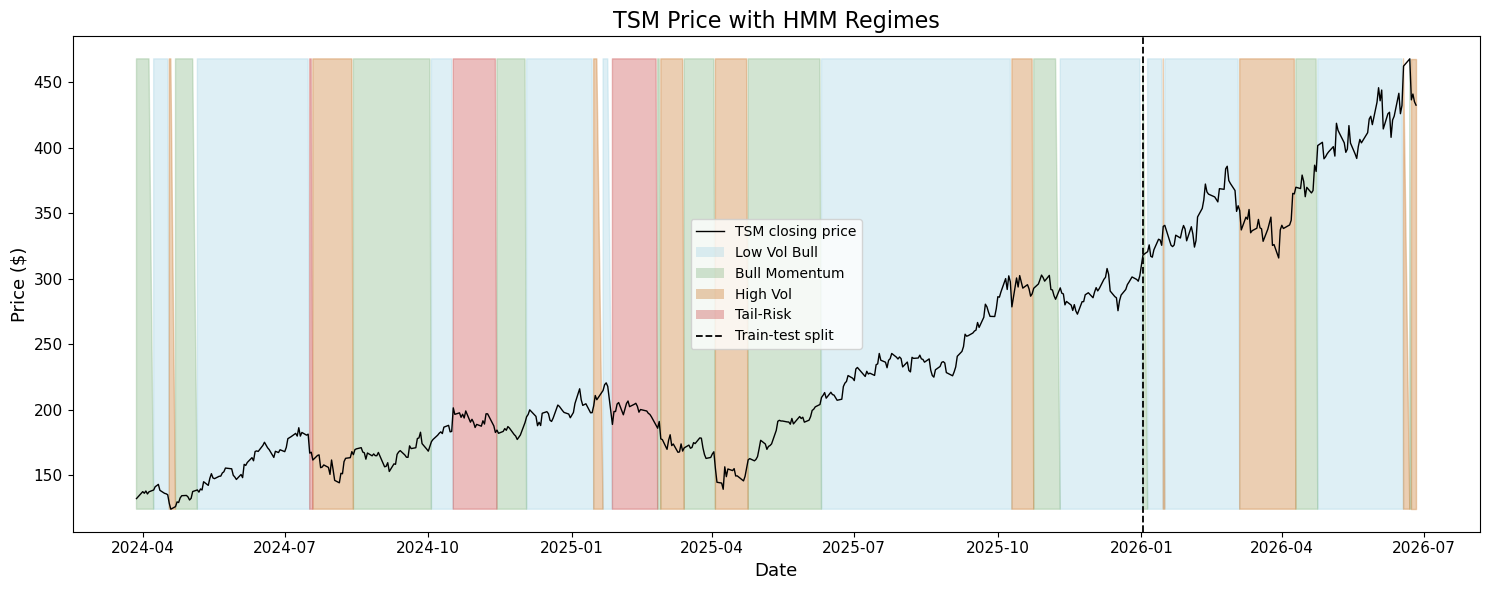

In [24]:
# Combine train and test for plotting only
plot_df = pd.concat(
    [
        train[["Close", "regime4"]],
        test[["Close", "regime4"]],
    ]
).sort_index()

test_start = test.index.min()

colors = [
    "lightblue",
    "darkseagreen",
    "peru",
    "indianred",
]

fig, ax = plt.subplots(figsize=(15, 6))

# Plot price across full sample
ax.plot(
    plot_df.index,
    plot_df["Close"],
    color="black",
    linewidth=1,
    zorder=3,
)

# Common y-range across both samples
y_min = plot_df["Close"].min()
y_max = plot_df["Close"].max()

# Shade regimes
for state in range(model4.n_components):
    mask = plot_df["regime4"].eq(state)

    ax.fill_between(
        plot_df.index,
        y_min,
        y_max,
        where=mask,
        color=colors[state],
        alpha=0.4,
        interpolate=True,
        zorder=1,
    )

# Mark train-test split
ax.axvline(
    test_start,
    color="black",
    linestyle="--",
    linewidth=1.3,
    zorder=4,
)

# Custom legend
legend_handles = [
    Line2D(
        [0],
        [0],
        color="black",
        linewidth=1,
        label="TSM closing price",
    ),
    *[
        Patch(
            facecolor=colors[state],
            alpha=0.4,
            label=regime4_names[state],
        )
        for state in range(model4.n_components)
    ],
    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=1.3,
        label="Train-test split",
    ),
]

ax.set_title("TSM Price with HMM Regimes", fontsize=16)
ax.set_xlabel("Date", fontsize=13)
ax.set_ylabel("Price ($)", fontsize=13)
ax.legend(handles=legend_handles, loc="best", fontsize=10)
ax.tick_params(
    axis="both",
    labelsize=11
)

plt.tight_layout()

plt.savefig(
    "TSM_combined_price_regimes.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

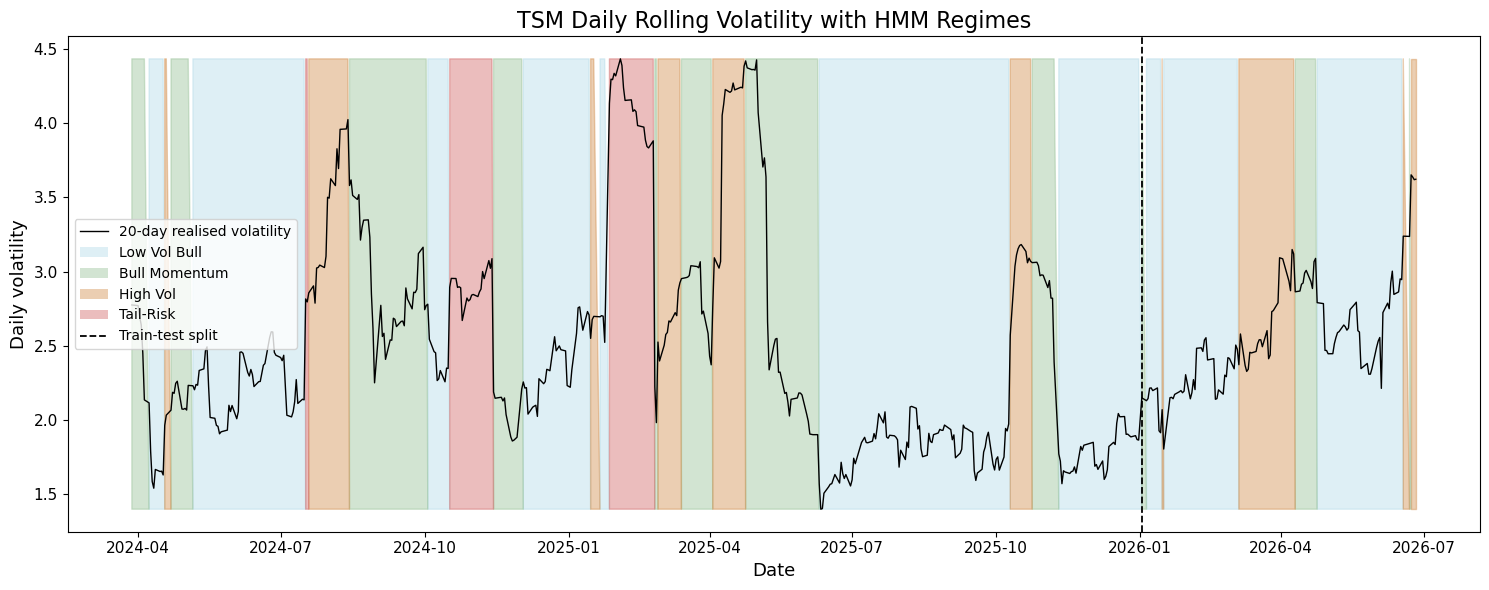

In [25]:

# Combine train and test for plotting only.
# The regime sequences remain those already decoded separately.
plot_df = pd.concat(
    [
        train[["rdv20", "regime4"]],
        test[["rdv20", "regime4"]],
    ]
).sort_index()

test_start = test.index.min()

fig, ax = plt.subplots(figsize=(15, 6))

# Plot 20-day realised volatility
ax.plot(
    plot_df.index,
    plot_df["rdv20"],
    color="black",
    linewidth=1,
    zorder=3,
)

# Common y-range across both samples
y_min = plot_df["rdv20"].min()
y_max = plot_df["rdv20"].max()

# Shade regimes across train and test
for state in range(model4.n_components):
    mask = plot_df["regime4"].eq(state)

    ax.fill_between(
        plot_df.index,
        y_min,
        y_max,
        where=mask,
        color=colors[state],
        alpha=0.4,
        interpolate=True,
        zorder=1,
    )

# Mark train-test boundary
ax.axvline(
    test_start,
    color="black",
    linestyle="--",
    linewidth=1.3,
    zorder=4,
)


# Custom legend avoids repeated regime labels
legend_handles = [
    Line2D(
        [0],
        [0],
        color="black",
        linewidth=1,
        label="20-day realised volatility",
    ),
    *[
        Patch(
            facecolor=colors[state],
            alpha=0.4,
            label=regime4_names[state],
        )
        for state in range(model4.n_components)
    ],
    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=1.3,
        label="Train-test split",
    ),
]

ax.set_title("TSM Daily Rolling Volatility with HMM Regimes", fontsize=16)
ax.set_xlabel("Date", fontsize=13)
ax.set_ylabel("Daily volatility", fontsize=13)
ax.legend(handles=legend_handles, loc="best", fontsize=10)
ax.tick_params(
    axis="both",
    labelsize=11
)
plt.tight_layout()

plt.savefig(
    "TSM_combined_volatility_regimes.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Given we are concerned majorly with the volatility behaviours intra-regime, a volatility summary may also prove useful.

In [27]:
state_volatility_summary = (
    TSM
    .dropna(subset=["regime4", "rdv20"])
    .groupby("regime4")["rdv20"]
    .agg(
        mean_volatility="mean",
        median_volatility="median",
        volatility_std="std",
        observations="count"
    )
)

print(state_volatility_summary)

         mean_volatility  median_volatility  volatility_std  observations
regime4                                                                  
0               2.117938           2.096246        0.354995           298
1               2.717978           2.689391        0.598805           134
2               3.073063           3.026899        0.607895            89
3               3.480245           3.080324        0.642636            42


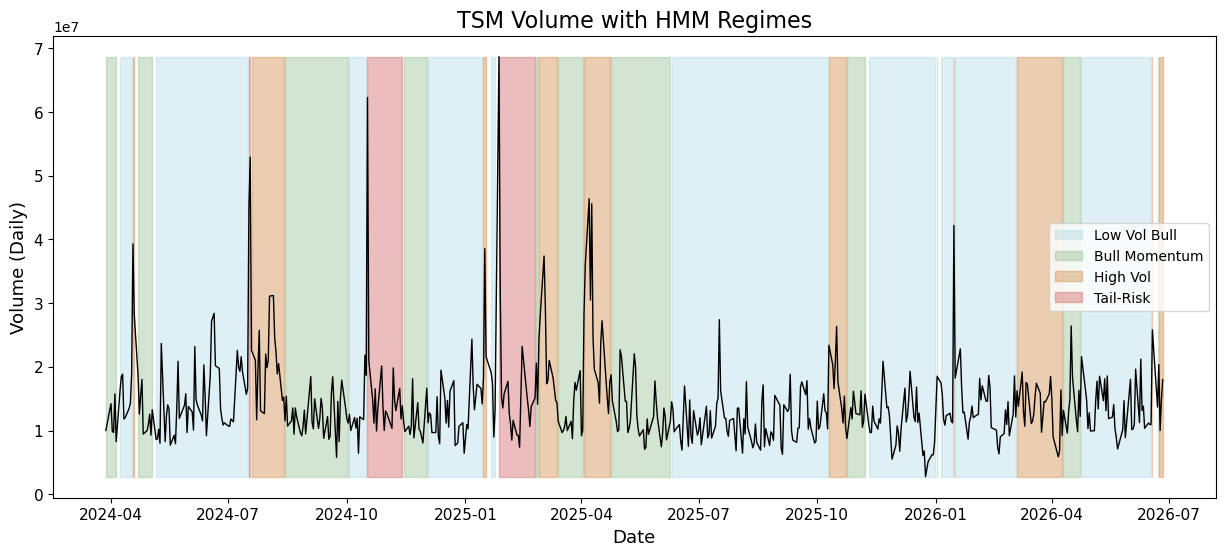

In [28]:
fig, ax = plt.subplots(figsize=(15,6))

ax.plot(TSM.index, TSM["Volume"], color="black", lw=1)

regime = TSM["regime4"]

for state in range(model4.n_components):

    mask = regime == state

    ax.fill_between(
        TSM.index,
        TSM["Volume"].min(),
        TSM["Volume"].max(),
        where=mask,
        color=colors[state],
        alpha=0.4,
        label=regime4_names[state]
    )

ax.set_title("TSM Volume with HMM Regimes", fontsize=16)
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Volume (Daily)', fontsize=13)
ax.tick_params(
    axis="both",
    labelsize=11
)
ax.legend(fontsize=10)
plt.savefig("TSM Volume",dpi=300,bbox_inches="tight")

plt.show()

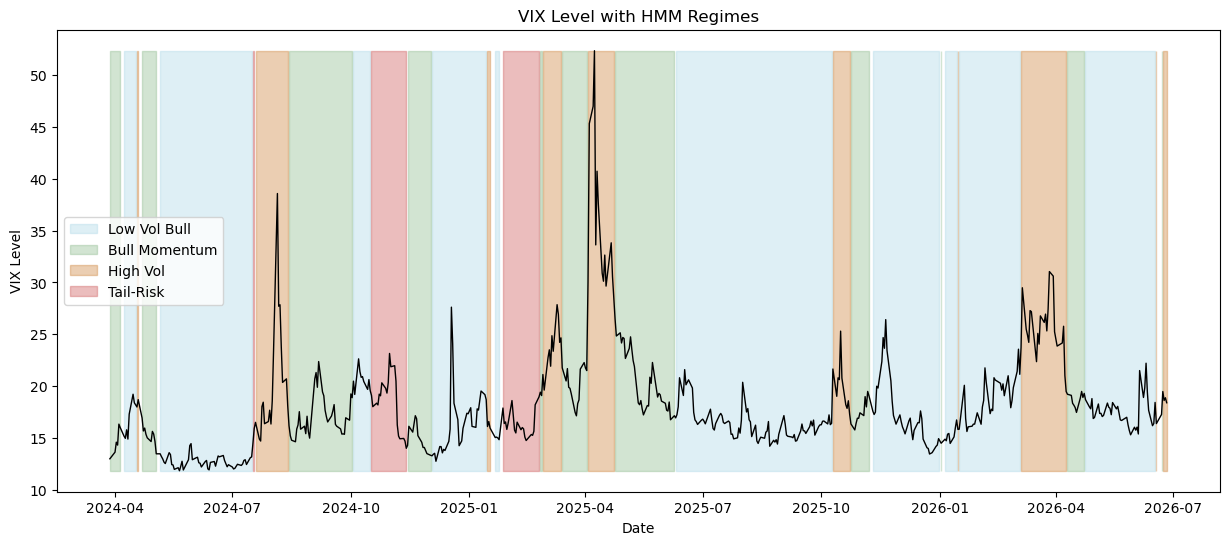

In [29]:
fig, ax = plt.subplots(figsize=(15,6))

ax.plot(TSM.index, TSM["vix_level"], color="black", lw=1)

regime = TSM["regime4"]

for state in range(model4.n_components):

    mask = regime == state

    ax.fill_between(
        TSM.index,
        TSM["vix_level"].min(),
        TSM["vix_level"].max(),
        where=mask,
        color=colors[state],
        alpha=0.4,
        label=regime4_names[state]
    )

ax.set_title("VIX Level with HMM Regimes")
ax.set_xlabel('Date')
ax.set_ylabel('VIX Level')
ax.legend()
#plt.savefig("TSM Volume",dpi=300,bbox_inches="tight")

plt.show()

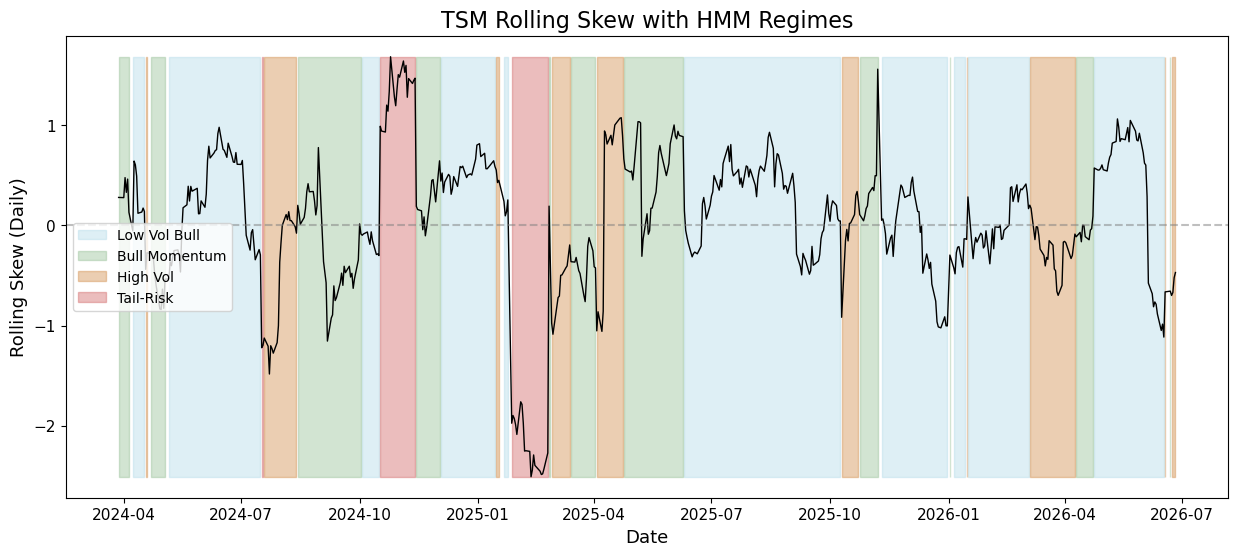

In [30]:
fig, ax = plt.subplots(figsize=(15,6))

ax.plot(TSM.index, TSM["rolling_skew"], color="black", lw=1)

regime = TSM["regime4"]
ax.axhline(y=0, color='grey', linestyle='--', alpha=0.5)

for state in range(model4.n_components):

    mask = regime == state

    ax.fill_between(
        TSM.index,
        TSM["rolling_skew"].min(),
        TSM["rolling_skew"].max(),
        where=mask,
        color=colors[state],
        alpha=0.4,
        label=regime4_names[state]
    )
ax.tick_params(
    axis="both",
    labelsize=11
)

ax.set_title("TSM Rolling Skew with HMM Regimes", fontsize=16)
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Rolling Skew (Daily)', fontsize=13)
ax.legend(fontsize=10)
plt.savefig("TSM skew",dpi=300,bbox_inches="tight")

plt.show()

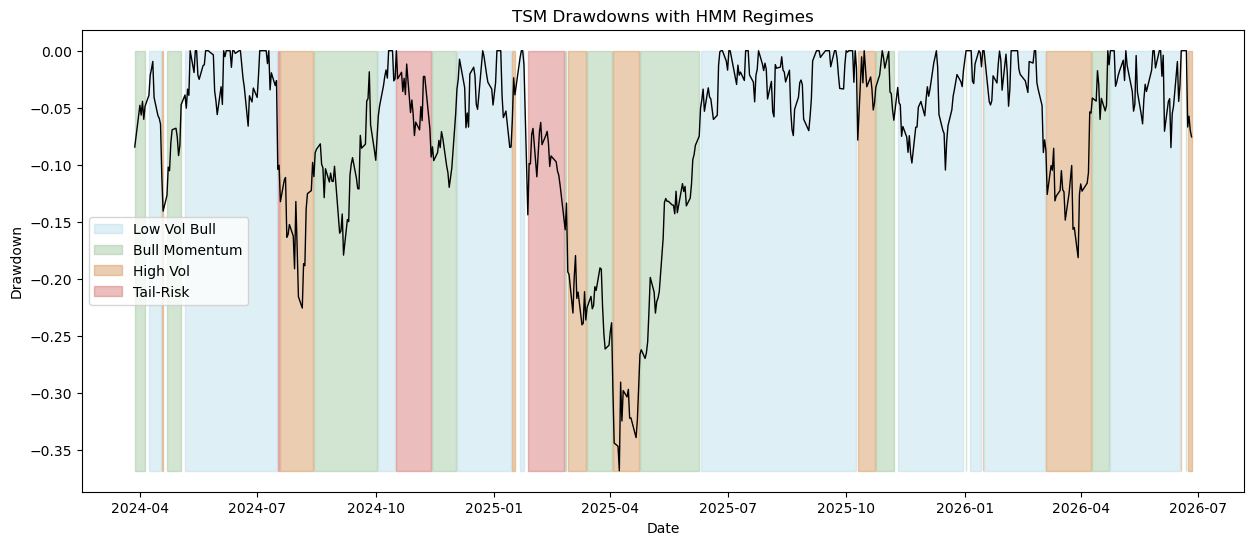

In [31]:
fig, ax = plt.subplots(figsize=(15,6))

ax.plot(TSM.index, TSM["Drawdown"], color="black", lw=1)

regime = TSM["regime4"]

for state in range(model4.n_components):

    mask = regime == state

    ax.fill_between(
        TSM.index,
        TSM["Drawdown"].min(),
        TSM["Drawdown"].max(),
        where=mask,
        color=colors[state],
        alpha=0.4,
        label=regime4_names[state]
    )

ax.set_title("TSM Drawdowns with HMM Regimes")
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown')
ax.legend()
#plt.savefig("TSM(test) vol_15",dpi=300,bbox_inches="tight")

plt.show()

## Regime Distributions by Plot

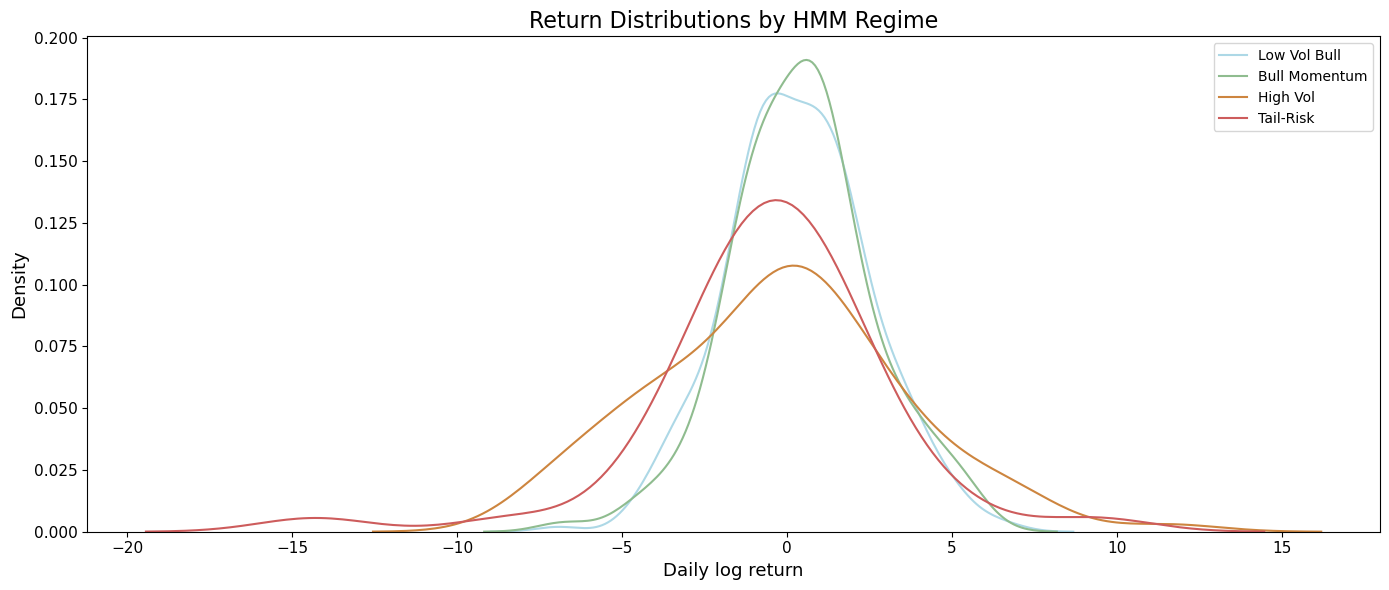

In [33]:
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

fig, ax = plt.subplots(figsize=(14, 6))

for state in range(model4.n_components):
    sns.kdeplot(
        data=TSM.loc[TSM["regime4"] == state],
        x="log_ret",
        label=regime4_names[state],
        color=colors[state],
        linewidth=1.5,
        ax=ax
    )

ax.set_title(
    "Return Distributions by HMM Regime",
    fontsize=16
)
ax.set_xlabel(
    "Daily log return",
    fontsize=13
)
ax.set_ylabel(
    "Density",
    fontsize=13
)

ax.tick_params(
    axis="both",
    labelsize=11
)

ax.legend(
    fontsize=10,
    loc="upper right"
)

plt.tight_layout()

plt.savefig(
    "Returns Distribution by Regime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Transition Matrix Heatmap

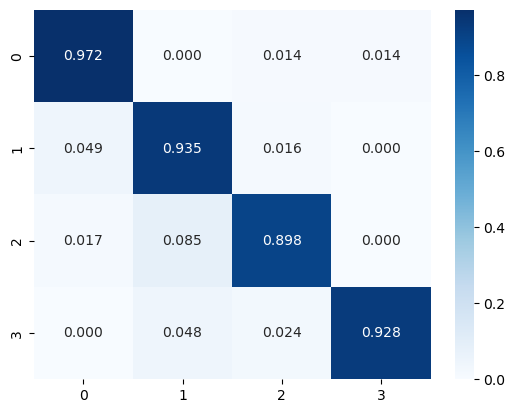

In [35]:
sns.heatmap(
    model4.transmat_,
    annot=True,
    fmt=".3f",
    cmap="Blues"
)

pd.set_option("display.float_format", lambda x: f"{x:.3f}")
plt.savefig(
    "Transition Matrix Heatmap",
    dpi=300,
    bbox_inches="tight"
)


We obtain an empirical transition matrix by counting the amount of times this state appears in the Viterbi decoded sequence.

In [37]:
regime = TSM["regime4"].values
n_states = model4.n_components

counts = np.zeros((n_states, n_states))

for t in range(len(regime) - 1):
    i = regime[t]
    j = regime[t + 1]
    counts[i, j] += 1

empirical_P = counts / counts.sum(axis=1, keepdims=True)

print("Model transition matrix:")
print(np.round(model4.transmat_, 3))

print("Empirical Viterbi transition matrix:")
print(np.round(empirical_P, 3))

Model transition matrix:
[[0.972 0.    0.014 0.014]
 [0.049 0.935 0.016 0.   ]
 [0.017 0.085 0.898 0.   ]
 [0.    0.048 0.024 0.928]]
Empirical Viterbi transition matrix:
[[0.966 0.003 0.02  0.01 ]
 [0.06  0.918 0.022 0.   ]
 [0.023 0.08  0.898 0.   ]
 [0.    0.048 0.024 0.929]]


In [38]:
difference = model4.transmat_ - empirical_P

# Frobenius norm
frob_norm = np.linalg.norm(difference, ord='fro')

print(f"Frobenius norm: {frob_norm:.6f}")

Frobenius norm: 0.024872


# Implementing a State-Dependent EWMA Model (Train)

In [40]:
data = train[["log_ret", "regime4"]].dropna().sort_index()

# Percentage returns improve numerical stability
returns = data["log_ret"].to_numpy(dtype=float) * 100
regimes = data["regime4"].to_numpy(dtype=int)

n_states = 4

In [41]:
def state_ewma_variance(returns, regimes, lambdas):
    """
    Produce one-step-ahead conditional variance estimates.

    Variance at time t uses the return and known state at t-1.
    """
    variance = np.empty(len(returns), dtype=float)

    # Initial variance
    variance[0] = np.var(returns, ddof=1)

    for t in range(1, len(returns)):
        state = regimes[t - 1]
        lam = lambdas[state]

        variance[t] = (
            lam * variance[t - 1]
            + (1.0 - lam) * returns[t - 1] ** 2
        )

    return variance

In [42]:
def ewma_nll(lambdas, returns, regimes):
    # Prevent invalid lambda values
    if np.any((lambdas <= 0) | (lambdas >= 1)):
        return 1e20

    variance = state_ewma_variance(
        returns,
        regimes,
        lambdas
    )

    variance = np.maximum(variance, 1e-10)

    # variance[t] forecasts the variance of returns[t]
    nll = 0.5 * np.sum(
        np.log(2.0 * np.pi)
        + np.log(variance[1:])
        + returns[1:] ** 2 / variance[1:]
    )

    return nll

In [43]:
initial_lambdas = np.array([
    0.97,  # State 0
    0.95,  # State 1
    0.90,  # State 2
    0.85   # State 3
])

result = minimize(
    ewma_nll,
    x0=initial_lambdas,
    args=(returns, regimes),
    method="L-BFGS-B",
    bounds=[(0.70, 0.995)] * n_states
)

if not result.success:
    raise RuntimeError(
        f"EWMA optimisation failed: {result.message}"
    )

estimated_lambdas = result.x

lambda_table = pd.DataFrame({
    "Regime": range(n_states),
    "Lambda": estimated_lambdas,
    "Shock Weight": 1.0 - estimated_lambdas
})

print(lambda_table.round(5))
print("Negative log-likelihood:", round(result.fun, 5))

   Regime  Lambda  Shock Weight
0       0   0.995         0.005
1       1   0.935         0.065
2       2   0.711         0.289
3       3   0.995         0.005
Negative log-likelihood: 3064.12596


In [44]:
ewma_variance = state_ewma_variance(
    returns,
    regimes,
    estimated_lambdas
)

data["ewma_variance"] = ewma_variance
data["ewma_volatility_pct"] = np.sqrt(ewma_variance)

train.loc[
    data.index,
    "ewma_volatility_pct"
] = data["ewma_volatility_pct"]

## Implementation of test part

In [46]:
test_data = test[["log_ret", "regime4"]].dropna().sort_index().copy()

test_returns = test_data["log_ret"].to_numpy(dtype=float) * 100
test_regimes = test_data["regime4"].to_numpy(dtype=int)

test_variance = np.empty(len(test_data), dtype=float)

# First test-day forecast uses final training-day information
last_lambda = estimated_lambdas[regimes[-1]]

test_variance[0] = (
    last_lambda * ewma_variance[-1]
    + (1 - last_lambda) * returns[-1] ** 2
)

# Remaining one-step-ahead forecasts
for t in range(1, len(test_data)):
    previous_state = test_regimes[t - 1]
    lam = estimated_lambdas[previous_state]

    test_variance[t] = (
        lam * test_variance[t - 1]
        + (1 - lam) * test_returns[t - 1] ** 2
    )

test_data["ewma_variance"] = test_variance
test_data["ewma_volatility_pct"] = np.sqrt(test_variance)
test_data["ewma_volatility"] = (
    test_data["ewma_volatility_pct"] / 100
)

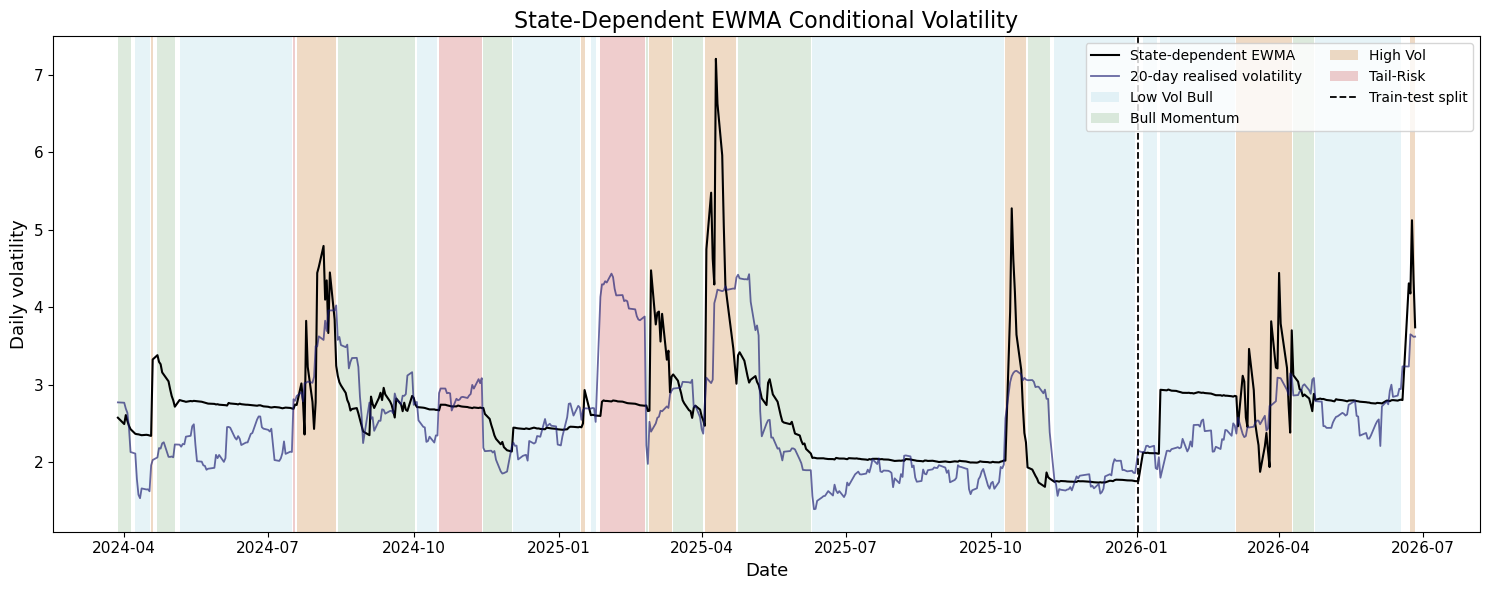

In [47]:
regime_labels = {
    0: "Low Vol Bull",
    1: "Bull Momentum",
    2: "High Vol",
    3: "Tail-Risk",
}

regime_colours = {
    0: "lightblue",
    1: "darkseagreen",
    2: "peru",
    3: "indianred",
}

# ----------------------------
# Prepare training-period data
# ----------------------------

train_plot = data[["ewma_volatility_pct", "regime4"]].copy()

train_plot["ewma_volatility"] = (
    train_plot["ewma_volatility_pct"] / 100
)

train_plot["realised_volatility"] = train["rdv20"]

train_plot = train_plot[
    ["ewma_volatility", "realised_volatility", "regime4"]
].dropna()

# ------------------------
# Prepare test-period data
# ------------------------

test_plot = test_data[
    ["ewma_volatility", "regime4"]
].copy()

test_plot["realised_volatility"] = test["rdv20"]

test_plot = test_plot[
    ["ewma_volatility", "realised_volatility", "regime4"]
].dropna()

# Combine for plotting only
combined_plot = pd.concat(
    [train_plot, test_plot]
).sort_index()

test_start = test_plot.index.min()

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    combined_plot.index,
    combined_plot["ewma_volatility"],
    color="black",
    linewidth=1.5,
    label="State-dependent EWMA",
    zorder=3,
)

ax.plot(
    combined_plot.index,
    combined_plot["realised_volatility"],
    color="midnightblue",
    linewidth=1.3,
    alpha=0.65,
    label="20-day realised volatility",
    zorder=3,
)

# Force a new episode at the train-test boundary
run_id = (
    combined_plot["regime4"].ne(
        combined_plot["regime4"].shift()
    )
    | (combined_plot.index == test_start)
).cumsum()

for _, episode in combined_plot.groupby(run_id):
    state = int(episode["regime4"].iloc[0])

    ax.axvspan(
        episode.index[0],
        episode.index[-1],
        color=regime_colours[state],
        alpha=0.3,
        linewidth=0,
        zorder=1,
    )

ax.axvline(
    test_start,
    color="black",
    linestyle="--",
    linewidth=1.3,
    zorder=4,
)

legend_handles = [
    Line2D(
        [0],
        [0],
        color="black",
        linewidth=1.5,
        label="State-dependent EWMA",
    ),
    Line2D(
        [0],
        [0],
        color="midnightblue",
        linewidth=1.3,
        alpha=0.65,
        label="20-day realised volatility",
    ),
    *[
        Patch(
            facecolor=regime_colours[state],
            alpha=0.3,
            label=regime_labels[state],
        )
        for state in regime_labels
    ],
    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=1.3,
        label="Train-test split",
    ),
]

ax.set_title(
    "State-Dependent EWMA Conditional Volatility",
    fontsize=16,
)
ax.set_xlabel("Date", fontsize=13)
ax.set_ylabel("Daily volatility", fontsize=13)
ax.tick_params(axis="both", labelsize=11)

ax.legend(
    handles=legend_handles,
    loc="upper right",
    fontsize=10,
    ncol=2,
)

plt.tight_layout()

plt.savefig(
    "EWMA_combined_conditional_volatility.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Evaluation of statistical metrics

In [49]:
evaluation = pd.DataFrame({
    "forecast_var": test_data["ewma_variance"] / 10000,
    "realised_var": test.loc[
        test_data.index,
        "rdv20"
    ] ** 2
}).dropna()

rmse = np.sqrt(
    np.mean(
        (
            np.sqrt(evaluation["forecast_var"])
            - np.sqrt(evaluation["realised_var"])
        ) ** 2
    )
)

mae = np.mean(
    np.abs(
        np.sqrt(evaluation["forecast_var"])
        - np.sqrt(evaluation["realised_var"])
    )
)

qlike = np.mean(
    np.log(evaluation["forecast_var"])
    + evaluation["realised_var"]
    / evaluation["forecast_var"]
)

print("Out-of-sample RMSE:", rmse)
print("Out-of-sample MAE:", mae)
print("Out-of-sample QLIKE:", qlike)

Out-of-sample RMSE: 0.49117186931169293
Out-of-sample MAE: 0.3845365899056245
Out-of-sample QLIKE: 2.923350861221067


# Implementing a Comparative EWMA Model (No Regime-Awareness)

In [51]:
# Training data
train_returns = train["log_ret"].dropna().to_numpy(dtype=float)

def ewma_variance(returns, lam):

    variance = np.empty(len(returns))
    variance[0] = np.var(returns, ddof=1)

    for t in range(1, len(returns)):

        variance[t] = (
            lam * variance[t-1]
            + (1 - lam) * returns[t-1]**2
        )

    return variance


def ewma_nll(lambda_array, returns):

    lam = lambda_array[0]

    if lam <= 0 or lam >= 1:
        return 1e20

    variance = ewma_variance(returns, lam)
    variance = np.maximum(variance, 1e-10)

    nll = 0.5 * np.sum(
        np.log(2 * np.pi)
        + np.log(variance[1:])
        + returns[1:]**2 / variance[1:]
    )

    return nll

result = minimize(
    ewma_nll,
    x0=np.array([0.94]),
    args=(train_returns,),
    method="L-BFGS-B",
    bounds=[(0.70, 0.995)]
)

common_lambda = result.x[0]

print("Estimated common lambda:", common_lambda)
print("Negative log-likelihood:", result.fun)

Estimated common lambda: 0.9794578891483973
Negative log-likelihood: 1043.864485941801


In [52]:
train_ewma_variance = ewma_variance(
    train_returns,
    common_lambda
)

test_returns = test["log_ret"].dropna().to_numpy(dtype=float)

test_ewma_variance = np.empty(len(test_returns))

test_ewma_variance[0] = (
    common_lambda * train_ewma_variance[-1]
    + (1 - common_lambda) * train_returns[-1]**2
)

for t in range(1, len(test_returns)):

    test_ewma_variance[t] = (
        common_lambda * test_ewma_variance[t-1]
        + (1 - common_lambda) * test_returns[t-1]**2
    )

general_ewma = test.loc[test["log_ret"].notna()].copy()

general_ewma["ewma_variance"] = test_ewma_variance
general_ewma["ewma_volatility"] = np.sqrt(test_ewma_variance)

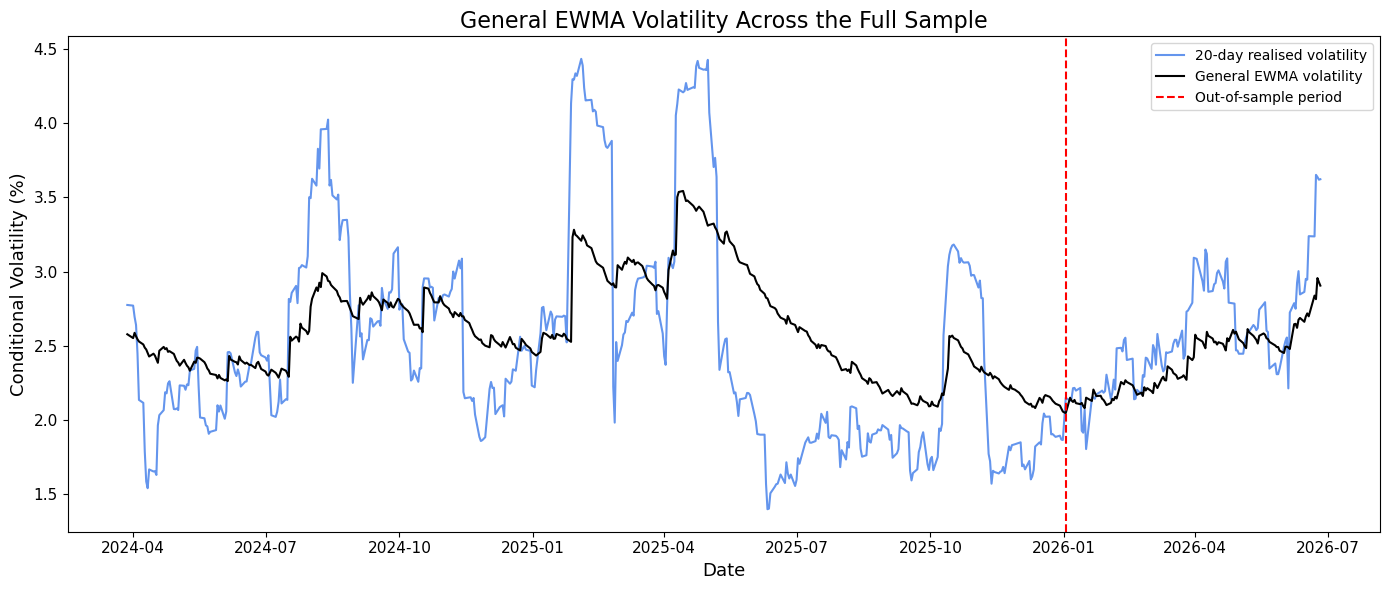

In [53]:
# Combine training and test data chronologically
full_data = pd.concat([
    train[["log_ret", "rdv20"]],
    test[["log_ret", "rdv20"]]
]).sort_index()

full_data = full_data[
    ~full_data.index.duplicated(keep="first")
].dropna(subset=["log_ret"]).copy()

full_returns = full_data["log_ret"].to_numpy(dtype=float)

# General EWMA variance over the entire period
full_ewma_variance = np.empty(len(full_returns))

# Initialise using the training-sample variance
full_ewma_variance[0] = np.var(
    train["log_ret"].dropna(),
    ddof=1
)

for t in range(1, len(full_returns)):

    full_ewma_variance[t] = (
        common_lambda * full_ewma_variance[t-1]
        + (1-common_lambda) * full_returns[t-1]**2
    )

full_data["general_ewma_volatility"] = np.sqrt(
    full_ewma_variance
)

# Plot the full period
fig, ax = plt.subplots(figsize=(14, 6))


ax.plot(
    full_data.index,
    full_data["rdv20"],
    color="cornflowerblue",
    linewidth=1.5,
    label="20-day realised volatility"
)

ax.plot(
    full_data.index,
    full_data["general_ewma_volatility"],
    color="black",
    linewidth=1.5,
    label="General EWMA volatility"
)


# Mark the train/test split
ax.axvline(
    test.index.min(),
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Out-of-sample period"
)

ax.set_title(
    "General EWMA Volatility Across the Full Sample",
    fontsize=16
)

ax.set_xlabel(
    "Date",
    fontsize=13
)

ax.set_ylabel(
    "Conditional Volatility (%)",
    fontsize=13
)

ax.tick_params(
    axis="both",
    labelsize=11
)

ax.legend(
    fontsize=10,
    loc="upper right"
)

plt.tight_layout()

plt.savefig(
    "General EWMA Full Sample.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Evaluation of statistical metrics once again

In [55]:
evaluation = general_ewma[
    ["ewma_volatility"]
].copy()

evaluation["realised_volatility"] = test.loc[
    evaluation.index,
    "rdv20"
]

evaluation = evaluation.dropna()

rmse = np.sqrt(
    np.mean(
        (
            evaluation["ewma_volatility"]
            - evaluation["realised_volatility"]
        )**2
    )
)

mae = np.mean(
    np.abs(
        evaluation["ewma_volatility"]
        - evaluation["realised_volatility"]
    )
)

forecast_variance = (
    evaluation["ewma_volatility"]**2
)

realised_variance = (
    evaluation["realised_volatility"]**2
)

qlike = np.mean(
    np.log(forecast_variance)
    + realised_variance / forecast_variance
)

print("General EWMA RMSE:", rmse)
print("General EWMA MAE:", mae)
print("General EWMA QLIKE:", qlike)

General EWMA RMSE: 0.2829916097289979
General EWMA MAE: 0.21634121525736527
General EWMA QLIKE: 2.8914171856012834


# Code for a Comparative General GARCH(1,1) Model

In [57]:
train = train.copy().sort_index()
test = test.copy().sort_index()

train_returns = (
    train["log_ret"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

test_returns = (
    test["log_ret"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

print("Training observations:", len(train_returns))
print("Test observations:", len(test_returns))

print(train_returns.describe())

Training observations: 442
Test observations: 121
count   442.000
mean      0.186
std       2.576
min     -14.303
25%      -1.209
50%       0.278
75%       1.548
max      11.595
Name: log_ret, dtype: float64


In [58]:
general_garch_model = arch_model(
    train_returns,
    mean="Constant",
    vol="GARCH",
    p=1,
    o=0,
    q=1,
    dist="t",
    rescale=False
)

general_garch_result = general_garch_model.fit(
    update_freq=0,
    disp="off",
    show_warning=True
)

print(general_garch_result.summary())

garch_parameters = general_garch_result.params

mu = garch_parameters["mu"]
omega = garch_parameters["omega"]
alpha = garch_parameters["alpha[1]"]
beta = garch_parameters["beta[1]"]
nu = garch_parameters["nu"]

persistence = alpha + beta

print("Mean return:", mu)
print("Omega:", omega)
print("Alpha:", alpha)
print("Beta:", beta)
print("Alpha + Beta:", persistence)
print("Student-t degrees of freedom:", nu)

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                      log_ret   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -1021.09
Distribution:      Standardized Student's t   AIC:                           2052.19
Method:                  Maximum Likelihood   BIC:                           2072.64
                                              No. Observations:                  442
Date:                      Wed, Aug 05 2026   Df Residuals:                      441
Time:                              13:13:01   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

### Extension of entire GARCH to OOS Testing

In [60]:
train["general_garch_volatility_pct"] = (
    general_garch_result.conditional_volatility
    .reindex(train.index)
)

training_plot = train[
    [
        "general_garch_volatility_pct",
        "rdv20",
        "regime4"
    ]
].dropna()

In [61]:
last_train_variance = float(
    general_garch_result.conditional_volatility.iloc[-1] ** 2
)

last_train_residual = float(
    general_garch_result.resid.iloc[-1]
)

test_forecast_variance = np.empty(
    len(test_returns)
)

previous_variance = last_train_variance
previous_residual = last_train_residual

for t in range(len(test_returns)):

    forecast_variance = (
        omega
        +
        alpha * previous_residual ** 2
        +
        beta * previous_variance
    )

    test_forecast_variance[t] = (
        forecast_variance
    )

    observed_return = float(
        test_returns.iloc[t]
    )

    observed_residual = (
        observed_return - mu
    )

    previous_variance = (
        forecast_variance
    )

    previous_residual = (
        observed_residual
    )

general_garch_forecasts = pd.DataFrame(
    {
        "general_garch_variance":
            test_forecast_variance,
        "general_garch_volatility_pct":
            np.sqrt(test_forecast_variance)
    },
    index=test_returns.index
)
test = test.join(
    general_garch_forecasts,
    how="left"
)

In [62]:
training_plot = train[
    [
        "general_garch_volatility_pct",
        "rdv20",
    ]
].replace(
    [np.inf, -np.inf],
    np.nan,
).dropna()

testing_plot = test[
    [
        "general_garch_volatility_pct",
        "rdv20",
    ]
].replace(
    [np.inf, -np.inf],
    np.nan,
).dropna()

## Plot of entire GARCH model

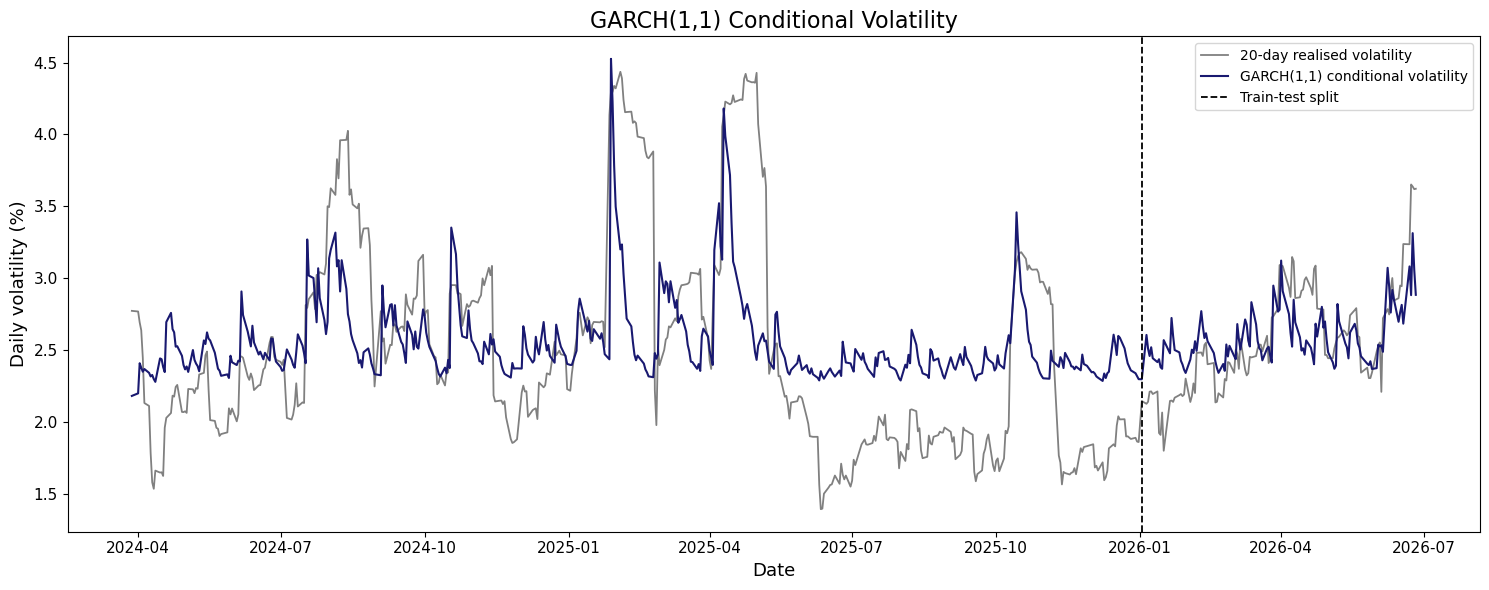

In [64]:
# Combine train and test for plotting
combined_plot = pd.concat(
    [training_plot, testing_plot]
).sort_index()

test_start = testing_plot.index.min()

fig, ax = plt.subplots(figsize=(15, 6))

# Realised-volatility proxy
ax.plot(
    combined_plot.index,
    combined_plot["rdv20"],
    color="grey",
    linewidth=1.3,
    label="20-day realised volatility",
)

# General GARCH conditional volatility
ax.plot(
    combined_plot.index,
    combined_plot["general_garch_volatility_pct"],
    color="midnightblue",
    linewidth=1.5,
    label="GARCH(1,1) conditional volatility",
)

# Mark the train-test split
ax.axvline(
    test_start,
    color="black",
    linestyle="--",
    linewidth=1.3,
    label="Train-test split",
)

ax.set_title(
    "GARCH(1,1) Conditional Volatility",
    fontsize=16,
)
ax.set_xlabel("Date", fontsize=13)
ax.set_ylabel("Daily volatility (%)", fontsize=13)
ax.tick_params(axis="both", labelsize=11)

ax.legend(
    loc="upper right",
    fontsize=10,
)

plt.tight_layout()

plt.savefig(
    "GARCH_Combined_Conditional_Volatility.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Evaluation of statistical metrics

In [66]:
def calculate_volatility_metrics(
    actual_volatility,
    forecast_volatility,
    variance_floor=1e-10
):

    forecast_error = (
        forecast_volatility
        -
        actual_volatility
    )

    rmse = np.sqrt(
        np.mean(
            forecast_error ** 2
        )
    )

    mae = np.mean(
        np.abs(
            forecast_error
        )
    )

    actual_variance = np.maximum(
        actual_volatility ** 2,
        variance_floor
    )

    forecast_variance = np.maximum(
        forecast_volatility ** 2,
        variance_floor
    )

    qlike = np.mean(
        np.log(forecast_variance)
        +
        actual_variance
        /
        forecast_variance
    )

    return {
        "RMSE": rmse,
        "MAE": mae,
        "QLIKE": qlike
    }



In [67]:
garch_metrics = calculate_volatility_metrics(
    test["rdv20"],
    test["general_garch_volatility_pct"]
)

garch_metrics

{'RMSE': 0.2816289206876212,
 'MAE': 0.2229621963300756,
 'QLIKE': 2.890987873790846}

## Extension to State-Dependent GARCH

In [69]:
train = train.copy().sort_index()
test = test.copy().sort_index()

train_data = (
    train[["log_ret", "regime4"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

test_data = (
    test[["log_ret", "regime4"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

train_returns = train_data["log_ret"].to_numpy(dtype=float)
train_regimes = train_data["regime4"].to_numpy(dtype=int)

test_returns = test_data["log_ret"].to_numpy(dtype=float)
test_regimes = test_data["regime4"].to_numpy(dtype=int)

n_states = 4

print("Training observations:", len(train_returns))
print("Test observations:", len(test_returns))

print("\nTraining regime counts:")
print(train_data["regime4"].value_counts().sort_index())

print("\nTest regime counts:")
print(test_data["regime4"].value_counts().sort_index())

Training observations: 442
Test observations: 121

Training regime counts:
regime4
0    220
1    122
2     58
3     42
Name: count, dtype: int64

Test regime counts:
regime4
0    78
1    12
2    31
Name: count, dtype: int64


### Parameter Transformation

In [71]:
def transform_parameters(parameters, n_states=4):

    mu = parameters[0]

    omega = np.exp(
        parameters[1:1 + n_states]
    )

    alpha_raw = np.exp(
        parameters[1 + n_states]
    )

    beta_raw = np.exp(
        parameters[2 + n_states]
    )

    denominator = (
        1.0
        + alpha_raw
        + beta_raw
    )

    alpha = alpha_raw / denominator
    beta = beta_raw / denominator

    return mu, omega, alpha, beta

### State-Dependent GARCH Recursion

In [73]:
def state_garch_variance(
    returns,
    regimes,
    mu,
    omega,
    alpha,
    beta,
    initial_variance=None
):

    n_obs = len(returns)

    variance = np.empty(n_obs)

    residuals = returns - mu

    if initial_variance is None:
        initial_variance = np.var(
            returns,
            ddof=1
        )

    variance[0] = max(
        initial_variance,
        1e-8
    )

    for t in range(1, n_obs):

        previous_state = int(
            regimes[t - 1]
        )

        variance[t] = (
            omega[previous_state]
            + alpha * residuals[t - 1] ** 2
            + beta * variance[t - 1]
        )

        variance[t] = max(
            variance[t],
            1e-8
        )

    return variance

### Gaussian Negative Log-Likelihood

In [75]:
def state_garch_nll(
    parameters,
    returns,
    regimes,
    n_states=4
):

    mu, omega, alpha, beta = (
        transform_parameters(
            parameters,
            n_states=n_states
        )
    )

    variance = state_garch_variance(
        returns=returns,
        regimes=regimes,
        mu=mu,
        omega=omega,
        alpha=alpha,
        beta=beta
    )

    residuals = returns - mu

    variance = np.maximum(
        variance,
        1e-8
    )

    log_likelihood = -0.5 * (
        np.log(2 * np.pi)
        + np.log(variance)
        + residuals ** 2 / variance
    )

    # Exclude the initial observation because its variance
    # was initialised rather than generated recursively.
    return -np.sum(
        log_likelihood[1:]
    )

### Parameter Intialisation

In [77]:
initial_mu = np.mean(train_returns)

overall_variance = np.var(
    train_returns,
    ddof=1
)

initial_alpha = 0.08
initial_beta = 0.88

initial_omega = np.empty(n_states)

for state in range(n_states):

    state_returns = train_returns[
        train_regimes == state
    ]

    if len(state_returns) >= 2:

        state_variance = np.var(
            state_returns,
            ddof=1
        )

    else:

        state_variance = overall_variance

    initial_omega[state] = max(
        state_variance
        * (1 - initial_alpha - initial_beta),
        1e-6
    )

In [78]:
remaining_weight = (
    1
    - initial_alpha
    - initial_beta
)

alpha_raw_initial = (
    initial_alpha
    / remaining_weight
)

beta_raw_initial = (
    initial_beta
    / remaining_weight
)

initial_parameters = np.concatenate(
    [
        [initial_mu],
        np.log(initial_omega),
        [
            np.log(alpha_raw_initial),
            np.log(beta_raw_initial)
        ]
    ]
)

### Model Fitting

In [80]:
state_garch_result = minimize(
    state_garch_nll,
    x0=initial_parameters,
    args=(
        train_returns,
        train_regimes,
        n_states
    ),
    method="L-BFGS-B",
    options={
        "maxiter": 2000,
        "ftol": 1e-10
    }
)

print("Optimisation successful:", state_garch_result.success)
print("Optimiser message:", state_garch_result.message)
print("Negative log-likelihood:", state_garch_result.fun)

Optimisation successful: True
Optimiser message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Negative log-likelihood: 1037.0974314222622


### Parameter Extraction

In [82]:
(
    state_mu,
    state_omega,
    state_alpha,
    state_beta
) = transform_parameters(
    state_garch_result.x,
    n_states=n_states
)

state_persistence = (
    state_alpha
    + state_beta
)

print("\nEstimated mean:", state_mu)

for state in range(n_states):

    print(
        f"Omega state {state}:",
        state_omega[state]
    )

print("Alpha:", state_alpha)
print("Beta:", state_beta)
print("Alpha + Beta:", state_persistence)


Estimated mean: 0.24761214993745698
Omega state 0: 0.12441341082127333
Omega state 1: 1.860608447521256e-06
Omega state 2: 0.001694700857372684
Omega state 3: 0.2381809044773161
Alpha: 0.01596647879569348
Beta: 0.9710826638034092
Alpha + Beta: 0.9870491425991027


In [83]:
train_state_variance = state_garch_variance(
    returns=train_returns,
    regimes=train_regimes,
    mu=state_mu,
    omega=state_omega,
    alpha=state_alpha,
    beta=state_beta
)

train_state_volatility = np.sqrt(
    train_state_variance
)

train_state_forecasts = pd.DataFrame(
    {
        "state_garch_variance":
            train_state_variance,
        "state_garch_volatility_pct":
            train_state_volatility
    },
    index=train_data.index
)

train = train.join(
    train_state_forecasts,
    how="left"
)

### Sequential OOS Forecasts

In [85]:
test_state_variance = np.empty(
    len(test_returns)
)

previous_variance = float(
    train_state_variance[-1]
)

previous_residual = float(
    train_returns[-1] - state_mu
)

previous_state = int(
    train_regimes[-1]
)

for t in range(len(test_returns)):

    forecast_variance = (
        state_omega[previous_state]
        + state_alpha * previous_residual ** 2
        + state_beta * previous_variance
    )

    forecast_variance = max(
        forecast_variance,
        1e-8
    )

    test_state_variance[t] = (
        forecast_variance
    )

    observed_residual = (
        test_returns[t]
        - state_mu
    )

    previous_variance = (
        forecast_variance
    )

    previous_residual = (
        observed_residual
    )

    previous_state = int(
        test_regimes[t]
    )

test_state_forecasts = pd.DataFrame(
    {
        "state_garch_variance":
            test_state_variance,
        "state_garch_volatility_pct":
            np.sqrt(test_state_variance)
    },
    index=test_data.index
)

test = test.join(
    test_state_forecasts,
    how="left"
)


In [86]:
comparison = test[
    [
        "rdv20",
        "general_garch_volatility_pct",
        "state_garch_volatility_pct"
    ]
].replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

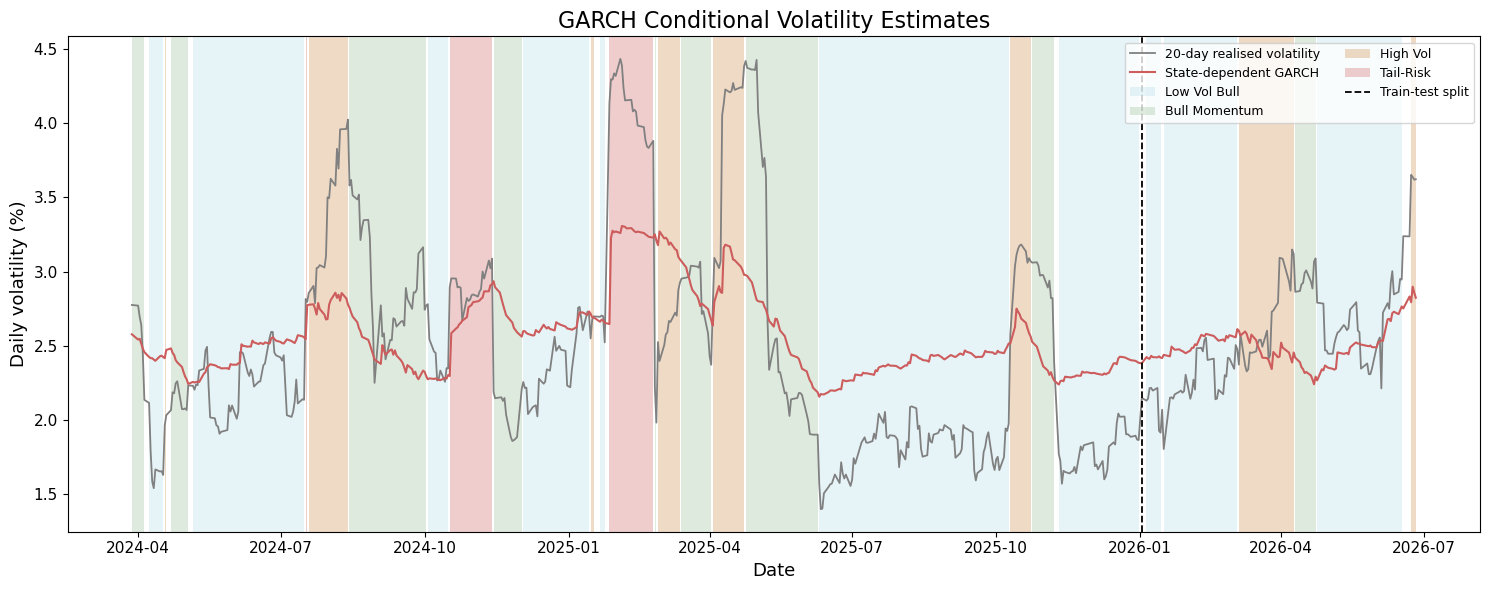

In [87]:
train_plot = train[
    [
        "state_garch_volatility_pct",
        "rdv20",
        "regime4",
    ]
].replace(
    [np.inf, -np.inf],
    np.nan,
).dropna()

# General GARCH is not shown in the training code supplied,
# so create an empty column for consistent concatenation.
train_plot["general_garch_volatility_pct"] = np.nan


test_plot = test[
    [
        "state_garch_volatility_pct",
        "general_garch_volatility_pct",
        "rdv20",
        "regime4",
    ]
].replace(
    [np.inf, -np.inf],
    np.nan,
)

test_plot = test_plot.dropna(
    subset=[
        "state_garch_volatility_pct",
        "rdv20",
        "regime4",
    ]
)

train_plot = train_plot[
    [
        "state_garch_volatility_pct",
        "general_garch_volatility_pct",
        "rdv20",
        "regime4",
    ]
]

combined_plot = pd.concat(
    [train_plot, test_plot]
).sort_index()

test_start = test_plot.index.min()

fig, ax = plt.subplots(figsize=(15, 6))

run_id = (
    combined_plot["regime4"].ne(
        combined_plot["regime4"].shift()
    )
    | (combined_plot.index == test_start)
).cumsum()

for _, episode in combined_plot.groupby(run_id):
    state = int(episode["regime4"].iloc[0])

    ax.axvspan(
        episode.index[0],
        episode.index[-1],
        color=regime_colours[state],
        alpha=0.3,
        linewidth=0,
        zorder=1,
    )

ax.plot(
    combined_plot.index,
    combined_plot["rdv20"],
    color="grey",
    linewidth=1.3,
    label="20-day realised volatility",
    zorder=3,
)

ax.plot(
    combined_plot.index,
    combined_plot["state_garch_volatility_pct"],
    color="indianred",
    linewidth=1.5,
    label="State-dependent GARCH",
    zorder=4,
)

ax.axvline(
    test_start,
    color="black",
    linestyle="--",
    linewidth=1.3,
    zorder=5,
)

line_handles = [
    Line2D(
        [0],
        [0],
        color="grey",
        linewidth=1.3,
        label="20-day realised volatility",
    ),
    Line2D(
        [0],
        [0],
        color="indianred",
        linewidth=1.5,
        label="State-dependent GARCH",
    )
]

regime_handles = [
    Patch(
        facecolor=regime_colours[state],
        alpha=0.3,
        label=regime_labels[state],
    )
    for state in regime_colours
]

split_handle = Line2D(
    [0],
    [0],
    color="black",
    linestyle="--",
    linewidth=1.3,
    label="Train-test split",
)

ax.legend(
    handles=line_handles + regime_handles + [split_handle],
    loc="upper right",
    fontsize=9,
    ncol=2,
)

ax.set_title(
    "GARCH Conditional Volatility Estimates",
    fontsize=16,
)
ax.set_xlabel("Date", fontsize=13)
ax.set_ylabel("Daily volatility (%)", fontsize=13)
ax.tick_params(axis="both", labelsize=11)

plt.tight_layout()

plt.savefig(
    "GARCH_Combined_state_Conditional_Volatility.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [88]:
general_garch_metrics = (
    calculate_volatility_metrics(
        comparison["rdv20"],
        comparison[
            "general_garch_volatility_pct"
        ]
    )
)

state_garch_metrics = (
    calculate_volatility_metrics(
        comparison["rdv20"],
        comparison[
            "state_garch_volatility_pct"
        ]
    )
)

garch_comparison_table = pd.DataFrame(
    [
        {
            "Model": "General GARCH(1,1)",
            **general_garch_metrics
        },
        {
            "Model": "State-dependent GARCH",
            **state_garch_metrics
        }
    ]
)

print(garch_comparison_table)

                   Model  RMSE   MAE  QLIKE
0     General GARCH(1,1) 0.282 0.223  2.891
1  State-dependent GARCH 0.357 0.287  2.908
